# Fusão Multimodal — Visual + Áudio + Texto
3 variantes de fusão: A (implícita), B (divergência), C (combinada)

Pipeline:
- Visual: AU .npy → LSTM → h_v
- Áudio: Wav2Vec .npy → LSTM → h_a  
- Texto: transcript → BERT → h_t
- Fusão A/B/C → MLP → sigmoid → 0/1

In [19]:
# CÉLULA 1: Imports e configuração
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === PATHS ===
#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
BASE_DIR = r'\ABAW\data'

SPLIT_DIR = os.path.join(BASE_DIR, 'split')
AU_DIR = os.path.join(BASE_DIR, 'au_features')
AUDIO_DIR = os.path.join(BASE_DIR, 'audio_features')

EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [20]:
# CÉLULA 2: Carregar splits com as 3 modalidades

def load_split_multimodal(split_file, au_dir, audio_dir, excluded_ids):
    data = []
    missing = {'au': 0, 'audio': 0, 'excluded': 0}
    
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]
            label = int(parts[1])
            text = parts[2] if len(parts) > 2 else ''
            
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1]  # com .mp4
            video_name_no_ext = video_name.replace('.mp4', '')
            
            if pid in excluded_ids:
                missing['excluded'] += 1
                continue
            
            # Buscar AU .npy
            au_path = os.path.join(au_dir, pid, f"{video_name_no_ext}.npy")
            if not os.path.exists(au_path):
                au_path = os.path.join(au_dir, pid, f"{video_name}.npy")
                if not os.path.exists(au_path):
                    missing['au'] += 1
                    continue
            
            # Buscar audio .npy
            audio_path = os.path.join(audio_dir, pid, f"{video_name_no_ext}.npy")
            if not os.path.exists(audio_path):
                audio_path = os.path.join(audio_dir, pid, f"{video_name}.npy")
                if not os.path.exists(audio_path):
                    missing['audio'] += 1
                    continue
            
            data.append({
                'pid': pid,
                'video_name': video_name,
                'au_path': au_path,
                'audio_path': audio_path,
                'text': text,
                'label': label
            })
    
    return data, missing

train_data, train_miss = load_split_multimodal(
    os.path.join(SPLIT_DIR, 'train.txt'), AU_DIR, AUDIO_DIR, EXCLUDED_IDS)
val_data, val_miss = load_split_multimodal(
    os.path.join(SPLIT_DIR, 'val.txt'), AU_DIR, AUDIO_DIR, EXCLUDED_IDS)
test_data, test_miss = load_split_multimodal(
    os.path.join(SPLIT_DIR, 'test.txt'), AU_DIR, AUDIO_DIR, EXCLUDED_IDS)

for name, data, miss in [('Train', train_data, train_miss),
                          ('Val', val_data, val_miss),
                          ('Test', test_data, test_miss)]:
    labels = [d['label'] for d in data]
    print(f"{name}: {len(data)} vídeos | AH={sum(labels)} ({sum(labels)/len(labels)*100:.1f}%) | "
          f"Missing: {miss}")

Train: 598 vídeos | AH=297 (49.7%) | Missing: {'au': 0, 'audio': 0, 'excluded': 180}
Val: 107 vídeos | AH=65 (60.7%) | Missing: {'au': 0, 'audio': 0, 'excluded': 17}
Test: 427 vídeos | AH=256 (60.0%) | Missing: {'au': 0, 'audio': 0, 'excluded': 98}


In [21]:
# CÉLULA 3: Dataset Multimodal

class MultimodalDataset(Dataset):
    def __init__(self, data_list, tokenizer, au_max_len=256, audio_max_len=512, 
                 text_max_len=128, au_stats=None):
        self.items = []
        self.tokenizer = tokenizer
        self.au_max_len = au_max_len
        self.audio_max_len = audio_max_len
        self.text_max_len = text_max_len
        
        # Pré-carregar e limpar AUs pra calcular stats
        au_arrays = []
        for item in data_list:
            au_seq = np.load(item['au_path']).astype(np.float64)
            au_seq = np.nan_to_num(au_seq, nan=0.0, posinf=1.0, neginf=0.0)
            au_seq = np.clip(au_seq, 0.0, 5.0)
            if len(au_seq) == 0:
                continue
            au_arrays.append(au_seq)
            self.items.append({
                'au_seq': au_seq,
                'audio_path': item['audio_path'],
                'text': item['text'],
                'label': item['label']
            })
        
        # Normalização das AUs
        if au_stats is None:
            all_frames = np.vstack(au_arrays)
            self.au_mean = np.mean(all_frames, axis=0)
            self.au_std = np.std(all_frames, axis=0)
            self.au_std[self.au_std < 1e-8] = 1.0
        else:
            self.au_mean, self.au_std = au_stats
    
    def get_au_stats(self):
        return (self.au_mean, self.au_std)
    
    def _pad_or_truncate(self, seq, max_len):
        """Pad ou trunca sequência temporal."""
        seq_len = len(seq)
        dim = seq.shape[1]
        if seq_len > max_len:
            # Amostragem uniforme
            indices = np.linspace(0, seq_len - 1, max_len, dtype=int)
            return seq[indices], np.ones(max_len)
        else:
            pad_len = max_len - seq_len
            padded = np.vstack([seq, np.zeros((pad_len, dim))])
            mask = np.concatenate([np.ones(seq_len), np.zeros(pad_len)])
            return padded, mask
    
    def __len__(self):
        return len(self.items)
    
    def __getitem__(self, idx):
        item = self.items[idx]
        
        # === Visual (AUs) ===
        au_seq = (item['au_seq'] - self.au_mean) / self.au_std
        au_padded, au_mask = self._pad_or_truncate(au_seq, self.au_max_len)
        
        # === Áudio ===
        audio_seq = np.load(item['audio_path']).astype(np.float32)
        audio_padded, audio_mask = self._pad_or_truncate(audio_seq, self.audio_max_len)
        
        # === Texto ===
        encoding = self.tokenizer(
            item['text'],
            max_length=self.text_max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'au_seq': torch.FloatTensor(au_padded),
            'au_mask': torch.FloatTensor(au_mask),
            'audio_seq': torch.FloatTensor(audio_padded),
            'audio_mask': torch.FloatTensor(audio_mask),
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.FloatTensor([item['label']])
        }


# Inicializar tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Criar datasets
AU_MAX_LEN = 256
AUDIO_MAX_LEN = 512   # ~10s a 50 frames/s do Wav2Vec
TEXT_MAX_LEN = 128
BATCH_SIZE = 16

train_dataset = MultimodalDataset(
    train_data, tokenizer, AU_MAX_LEN, AUDIO_MAX_LEN, TEXT_MAX_LEN)
au_stats = train_dataset.get_au_stats()
val_dataset = MultimodalDataset(
    val_data, tokenizer, AU_MAX_LEN, AUDIO_MAX_LEN, TEXT_MAX_LEN, au_stats=au_stats)
test_dataset = MultimodalDataset(
    test_data, tokenizer, AU_MAX_LEN, AUDIO_MAX_LEN, TEXT_MAX_LEN, au_stats=au_stats)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=0)

# Verificar
batch = next(iter(train_loader))
print(f"AU: {batch['au_seq'].shape}")       # (B, 256, 20)
print(f"Audio: {batch['audio_seq'].shape}")  # (B, 512, 768)
print(f"Text: {batch['input_ids'].shape}")   # (B, 128)
print(f"Label: {batch['label'].shape}")      # (B, 1)
print(f"\nNaN check: au={torch.isnan(batch['au_seq']).any()}, "
      f"audio={torch.isnan(batch['audio_seq']).any()}")
print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

AU: torch.Size([16, 256, 20])
Audio: torch.Size([16, 512, 768])
Text: torch.Size([16, 128])
Label: torch.Size([16, 1])

NaN check: au=False, audio=False

Train: 598 | Val: 107 | Test: 427


In [22]:
# CÉLULA 4: Modelo Multimodal com 3 variantes de fusão

class MultimodalAHDetector(nn.Module):
    def __init__(self, fusion_type='C', hidden_dim=128, dropout=0.3,
                 freeze_bert=True):
        super().__init__()
        self.fusion_type = fusion_type
        proj_dim = hidden_dim  # 128
        
        # === Visual encoder (AUs → LSTM → h_v) ===
        self.visual_lstm = nn.LSTM(
            input_size=20, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        self.visual_attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.visual_proj = nn.Linear(hidden_dim * 2, proj_dim)
        
        # === Audio encoder (Wav2Vec embeddings → LSTM → h_a) ===
        self.audio_input_proj = nn.Linear(768, hidden_dim)  # reduzir dim antes do LSTM
        self.audio_lstm = nn.LSTM(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        self.audio_attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.audio_proj = nn.Linear(hidden_dim * 2, proj_dim)
        
        # === Text encoder (BERT → h_t) ===
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False
            # Descongelar últimas 2 camadas
            for param in self.bert.encoder.layer[-2:].parameters():
                param.requires_grad = True
        self.text_proj = nn.Linear(768, proj_dim)
        
        # === Classifier ===
        if fusion_type == 'A':      # concat(h_v', h_a', h_t')
            cls_input = proj_dim * 3
        elif fusion_type == 'B':    # concat(divergências)
            cls_input = proj_dim * 3
        elif fusion_type == 'C':    # concat(A + B)
            cls_input = proj_dim * 6
        
        self.classifier = nn.Sequential(
            nn.Linear(cls_input, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def _attend(self, lstm_out, mask, attn_layer):
        """Attention pooling com mask."""
        weights = attn_layer(lstm_out).squeeze(-1)
        weights = weights.masked_fill(mask == 0, float('-inf'))
        weights = torch.softmax(weights, dim=1)
        return torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
    
    def encode_visual(self, au_seq, au_mask):
        lstm_out, _ = self.visual_lstm(au_seq)
        h_v = self._attend(lstm_out, au_mask, self.visual_attn)
        return self.visual_proj(h_v)
    
    def encode_audio(self, audio_seq, audio_mask):
        audio_proj = self.audio_input_proj(audio_seq)
        lstm_out, _ = self.audio_lstm(audio_proj)
        h_a = self._attend(lstm_out, audio_mask, self.audio_attn)
        return self.audio_proj(h_a)
    
    def encode_text(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h_t = outputs.last_hidden_state[:, 0]  # [CLS]
        return self.text_proj(h_t)
    
    def forward(self, au_seq, au_mask, audio_seq, audio_mask, input_ids, attention_mask):
        # Encode cada modalidade → vetor proj_dim
        h_v = self.encode_visual(au_seq, au_mask)        # (B, 128)
        h_a = self.encode_audio(audio_seq, audio_mask)   # (B, 128)
        h_t = self.encode_text(input_ids, attention_mask) # (B, 128)
        
        # Fusão
        if self.fusion_type == 'A':
            fused = torch.cat([h_v, h_a, h_t], dim=1)
        elif self.fusion_type == 'B':
            d_va = torch.abs(h_v - h_a)
            d_vt = torch.abs(h_v - h_t)
            d_at = torch.abs(h_a - h_t)
            fused = torch.cat([d_va, d_vt, d_at], dim=1)
        elif self.fusion_type == 'C':
            d_va = torch.abs(h_v - h_a)
            d_vt = torch.abs(h_v - h_t)
            d_at = torch.abs(h_a - h_t)
            fused = torch.cat([h_v, h_a, h_t, d_va, d_vt, d_at], dim=1)
        
        return self.classifier(fused)


# Contar parâmetros
for ft in ['A', 'B', 'C']:
    m = MultimodalAHDetector(fusion_type=ft)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Fusão {ft}: {total:,} total | {trainable:,} treináveis")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusão A: 111,043,843 total | 15,737,347 treináveis


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusão B: 111,043,843 total | 15,737,347 treináveis


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusão C: 111,092,995 total | 15,786,499 treináveis


In [23]:
# CÉLULA 5: Função de treino genérica

def train_model(model, train_loader, val_loader, n_epochs=30, lr=5e-4,
                patience=8, model_name='model'):
    
    # Class weight
    n_pos = sum(d['label'] for d in train_data)
    n_neg = len(train_data) - n_pos
    pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Optimizer com lr diferenciado: BERT menor, resto maior
    bert_params = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
    other_params = [p for n, p in model.named_parameters() if 'bert' not in n and p.requires_grad]
    
    optimizer = torch.optim.AdamW([
        {'params': bert_params, 'lr': lr * 0.1},  # BERT: lr/10
        {'params': other_params, 'lr': lr}
    ], weight_decay=1e-4)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    best_val_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_f1': []}
    
    for epoch in range(n_epochs):
        # --- Train ---
        model.train()
        total_loss = 0
        n_batches = 0
        
        for batch in train_loader:
            au_seq = batch['au_seq'].to(device)
            au_mask = batch['au_mask'].to(device)
            audio_seq = batch['audio_seq'].to(device)
            audio_mask = batch['audio_mask'].to(device)
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            logits = model(au_seq, au_mask, audio_seq, audio_mask, input_ids, attn_mask)
            loss = criterion(logits, labels)
            
            if torch.isnan(loss):
                continue
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        avg_loss = total_loss / max(n_batches, 1)
        
        # --- Validation ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                au_seq = batch['au_seq'].to(device)
                au_mask = batch['au_mask'].to(device)
                audio_seq = batch['audio_seq'].to(device)
                audio_mask = batch['audio_mask'].to(device)
                input_ids = batch['input_ids'].to(device)
                attn_mask = batch['attention_mask'].to(device)
                
                logits = model(au_seq, au_mask, audio_seq, audio_mask, input_ids, attn_mask)
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_preds.extend(preds.cpu().numpy().flatten())
                all_labels.extend(batch['label'].numpy().flatten())
        
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(BASE_DIR, f'best_{model_name}.pt'))
        else:
            patience_counter += 1
        
        if (epoch + 1) % 3 == 0 or patience_counter == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
                  f"| Best: {best_val_f1:.4f} {'*' if patience_counter == 0 else ''}")
        
        if patience_counter >= patience:
            print(f"  Early stopping na epoch {epoch+1}")
            break
    
    # Carregar melhor modelo
    model.load_state_dict(torch.load(os.path.join(BASE_DIR, f'best_{model_name}.pt')))
    return model, history, best_val_f1


def evaluate_model(model, loader, split_name='Test'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            au_seq = batch['au_seq'].to(device)
            au_mask = batch['au_mask'].to(device)
            audio_seq = batch['audio_seq'].to(device)
            audio_mask = batch['audio_mask'].to(device)
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            
            logits = model(au_seq, au_mask, audio_seq, audio_mask, input_ids, attn_mask)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(batch['label'].numpy().flatten())
    
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\n{split_name} Macro F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['No AH', 'AH']))
    return f1

print("Funções de treino prontas.")

Funções de treino prontas.


In [24]:
# CÉLULA 6: Treinar Fusão A (implícita — concatenação)
print("=" * 50)
print("FUSÃO A — Implícita (concat h_v, h_a, h_t)")
print("=" * 50)

model_A = MultimodalAHDetector(fusion_type='A', hidden_dim=128, dropout=0.3).to(device)
model_A, hist_A, val_f1_A = train_model(
    model_A, train_loader, val_loader, 
    n_epochs=30, lr=5e-4, patience=8, model_name='fusion_A'
)
test_f1_A = evaluate_model(model_A, test_loader, 'Fusão A - Test')

FUSÃO A — Implícita (concat h_v, h_a, h_t)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6648 | Val F1: 0.6257 | Best: 0.6257 *
  Epoch   3 | Loss: 0.4944 | Val F1: 0.6822 | Best: 0.6822 *
  Epoch   6 | Loss: 0.2001 | Val F1: 0.6277 | Best: 0.6822 
  Epoch   9 | Loss: 0.0921 | Val F1: 0.6306 | Best: 0.6822 
  Early stopping na epoch 11

Fusão A - Test Macro F1: 0.6604
              precision    recall  f1-score   support

       No AH       0.55      0.82      0.66       171
          AH       0.82      0.55      0.66       256

    accuracy                           0.66       427
   macro avg       0.69      0.69      0.66       427
weighted avg       0.71      0.66      0.66       427



In [25]:
# CÉLULA 7: Treinar Fusão B (explícita — divergência)
print("=" * 50)
print("FUSÃO B — Explícita (divergência entre modalidades)")
print("=" * 50)

model_B = MultimodalAHDetector(fusion_type='B', hidden_dim=128, dropout=0.3).to(device)
model_B, hist_B, val_f1_B = train_model(
    model_B, train_loader, val_loader,
    n_epochs=30, lr=5e-4, patience=8, model_name='fusion_B'
)
test_f1_B = evaluate_model(model_B, test_loader, 'Fusão B - Test')

FUSÃO B — Explícita (divergência entre modalidades)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6879 | Val F1: 0.5723 | Best: 0.5723 *
  Epoch   2 | Loss: 0.6087 | Val F1: 0.5996 | Best: 0.5996 *
  Epoch   3 | Loss: 0.5384 | Val F1: 0.6030 | Best: 0.6030 *
  Epoch   4 | Loss: 0.4454 | Val F1: 0.6046 | Best: 0.6046 *
  Epoch   6 | Loss: 0.2926 | Val F1: 0.6007 | Best: 0.6046 
  Epoch   7 | Loss: 0.2423 | Val F1: 0.6359 | Best: 0.6359 *
  Epoch   9 | Loss: 0.0937 | Val F1: 0.6162 | Best: 0.6359 
  Epoch  12 | Loss: 0.0305 | Val F1: 0.6134 | Best: 0.6359 
  Epoch  15 | Loss: 0.0194 | Val F1: 0.5918 | Best: 0.6359 
  Early stopping na epoch 15

Fusão B - Test Macro F1: 0.6808
              precision    recall  f1-score   support

       No AH       0.58      0.73      0.65       171
          AH       0.78      0.65      0.71       256

    accuracy                           0.68       427
   macro avg       0.68      0.69      0.68       427
weighted avg       0.70      0.68      0.69       427



In [26]:
# CÉLULA 8: Treinar Fusão C (combinada — A + B)
print("=" * 50)
print("FUSÃO C — Combinada (conteúdo + divergência)")
print("=" * 50)

model_C = MultimodalAHDetector(fusion_type='C', hidden_dim=128, dropout=0.3).to(device)
model_C, hist_C, val_f1_C = train_model(
    model_C, train_loader, val_loader,
    n_epochs=30, lr=5e-4, patience=8, model_name='fusion_C'
)
test_f1_C = evaluate_model(model_C, test_loader, 'Fusão C - Test')

FUSÃO C — Combinada (conteúdo + divergência)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6756 | Val F1: 0.5848 | Best: 0.5848 *
  Epoch   3 | Loss: 0.5384 | Val F1: 0.6377 | Best: 0.6377 *
  Epoch   6 | Loss: 0.2694 | Val F1: 0.6126 | Best: 0.6377 
  Epoch   9 | Loss: 0.1203 | Val F1: 0.6441 | Best: 0.6441 *
  Epoch  12 | Loss: 0.0389 | Val F1: 0.6194 | Best: 0.6441 
  Epoch  15 | Loss: 0.0005 | Val F1: 0.6556 | Best: 0.6556 *
  Epoch  18 | Loss: 0.0044 | Val F1: 0.6154 | Best: 0.6556 
  Epoch  21 | Loss: 0.0111 | Val F1: 0.6126 | Best: 0.6556 
  Early stopping na epoch 23

Fusão C - Test Macro F1: 0.6766
              precision    recall  f1-score   support

       No AH       0.59      0.67      0.63       171
          AH       0.76      0.70      0.73       256

    accuracy                           0.68       427
   macro avg       0.68      0.68      0.68       427
weighted avg       0.69      0.68      0.69       427



RESULTADOS FINAIS
Modelo                             Val F1    Test F1
--------------------------------------------------
Challenge baseline                      —     0.2827
Visual (XGBoost)                   0.6194     0.5642
Visual (LSTM)                      0.5723     0.5266
Texto (BERT)                       0.5758     0.5904
--------------------------------------------------
Fusão A (implícita)                0.6822     0.6604
Fusão B (divergência)              0.6359     0.6808
Fusão C (combinada)                0.6556     0.6766


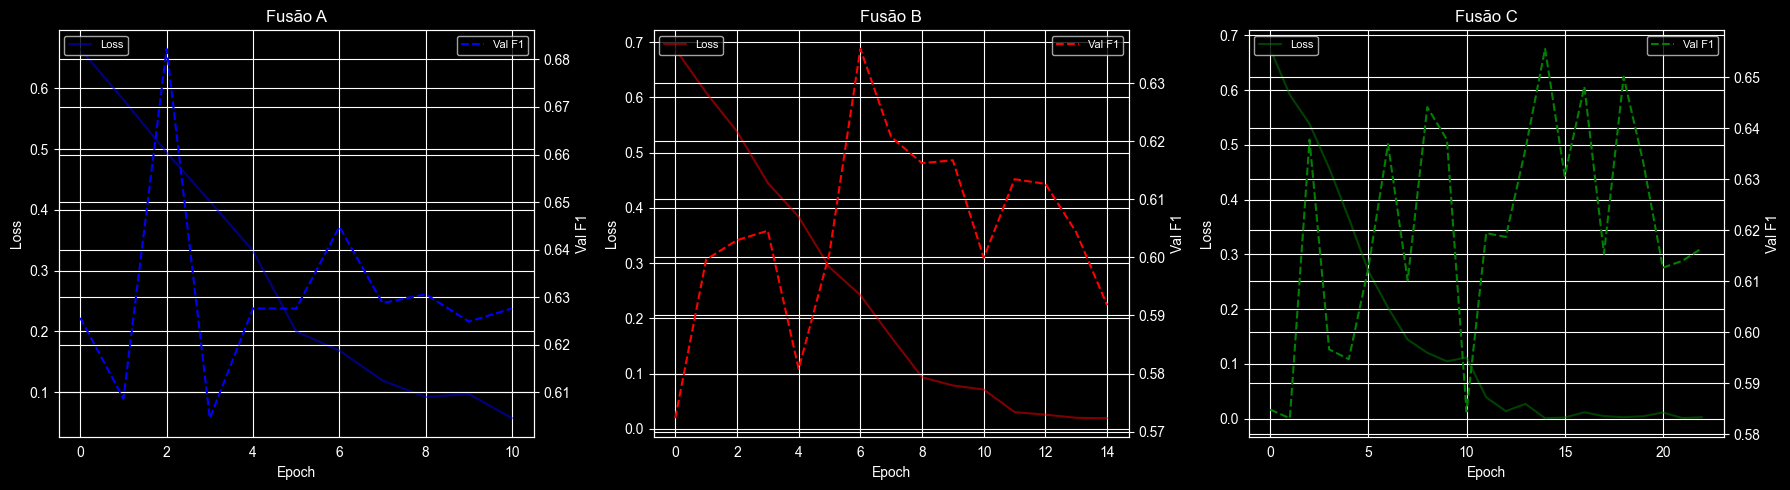

In [27]:
# CÉLULA 9: Comparativo final + gráficos

print("=" * 60)
print("RESULTADOS FINAIS")
print("=" * 60)
print(f"{'Modelo':<30} {'Val F1':>10} {'Test F1':>10}")
print("-" * 50)
print(f"{'Challenge baseline':<30} {'—':>10} {'0.2827':>10}")
print(f"{'Visual (XGBoost)':<30} {'0.6194':>10} {'0.5642':>10}")
print(f"{'Visual (LSTM)':<30} {'0.5723':>10} {'0.5266':>10}")
print(f"{'Texto (BERT)':<30} {'0.5758':>10} {'0.5904':>10}")
print("-" * 50)
print(f"{'Fusão A (implícita)':<30} {val_f1_A:>10.4f} {test_f1_A:>10.4f}")
print(f"{'Fusão B (divergência)':<30} {val_f1_B:>10.4f} {test_f1_B:>10.4f}")
print(f"{'Fusão C (combinada)':<30} {val_f1_C:>10.4f} {test_f1_C:>10.4f}")
print("=" * 60)

# Gráficos de treino
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, hist, name, color in [
    (axes[0], hist_A, 'Fusão A', 'blue'),
    (axes[1], hist_B, 'Fusão B', 'red'),
    (axes[2], hist_C, 'Fusão C', 'green')
]:
    ax2 = ax.twinx()
    ax.plot(hist['train_loss'], color=color, alpha=0.5, label='Loss')
    ax2.plot(hist['val_f1'], color=color, linestyle='--', label='Val F1')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel('Val F1')
    ax.set_title(name)
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()